     Country  Neighbourhood  Government  Scientist  Journalist  \
0    Albania         0.5072      0.4357     0.4919      0.5349   
1    Algeria         0.6730      0.6498     0.8442      0.4431   
2  Argentina         0.7587      0.4352     0.8937      0.5281   
3  Australia         0.9221      0.7449     0.9385      0.7131   
4    Austria         0.8844      0.7387     0.9568      0.7535   

   Doctor and Nurses  Philantropist  Traditional Healers  
0             0.6903         0.5468               0.4243  
1             0.8113         0.6835               0.7409  
2             0.9246         0.7140               0.1394  
3             0.9809         0.8726               0.5733  
4             0.9699         0.8212               0.6115  
(113, 8)
               Country  Cluster
0              Albania        0
1              Algeria        0
2            Argentina        0
3            Australia        0
4              Austria        0
5              Bahrain        0
6           Bang

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_11859/2044894600.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


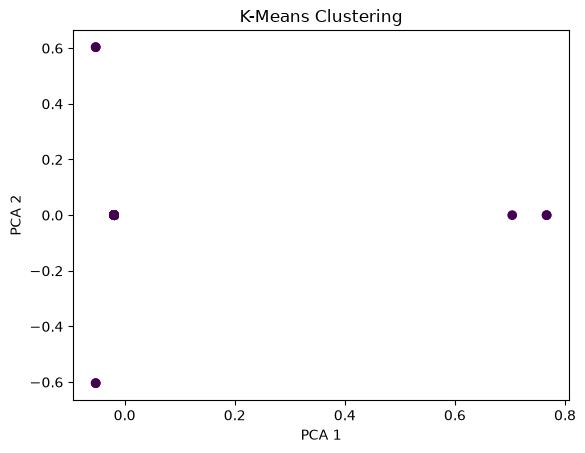

In [1]:
# 1. Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("global_trust-rate.csv")
print(df.head())
print(df.shape)

# 3. Find text column
text_col = df.select_dtypes(include="object").columns[0]
text = df[text_col].fillna("")

# 4. NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=500)
X = tfidf.fit_transform(text)

# 5. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 6. Show results
print(df[[text_col, "Cluster"]].head(20))

# 7. Visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering")
plt.show()

# 8. Save results
df.to_csv("global_trust-rate_clustered.csv", index=False)